### Import Library

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler, MinMaxScaler, LabelEncoder, label_binarize
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.datasets import load_iris
from imblearn.over_sampling import BorderlineSMOTE
from imblearn.under_sampling import RandomUnderSampler, NearMiss
from imblearn.combine import SMOTETomek
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report, f1_score, precision_score, recall_score, roc_auc_score, roc_curve, auc
from sklearn.utils.class_weight import compute_class_weight
import skfuzzy as fuzz
from collections import Counter
from scipy import stats
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')

### Run the Iris Data (Test First)

Epoch [10/200] Loss: 0.4295  Test Acc: 0.8667
Epoch [20/200] Loss: 0.2642  Test Acc: 0.9111
Epoch [30/200] Loss: 0.2366  Test Acc: 0.9111
Epoch [40/200] Loss: 0.2298  Test Acc: 0.9111
Epoch [50/200] Loss: 0.2276  Test Acc: 0.9111
Epoch [60/200] Loss: 0.2268  Test Acc: 0.9111
Epoch [70/200] Loss: 0.2273  Test Acc: 0.9111
Epoch [80/200] Loss: 0.2262  Test Acc: 0.9111
Epoch [90/200] Loss: 0.2249  Test Acc: 0.9111
Epoch [100/200] Loss: 0.2247  Test Acc: 0.9111
Epoch [110/200] Loss: 0.2244  Test Acc: 0.9111
Epoch [120/200] Loss: 0.2248  Test Acc: 0.9111
Epoch [130/200] Loss: 0.2259  Test Acc: 0.9111
Epoch [140/200] Loss: 0.2239  Test Acc: 0.9111
Epoch [150/200] Loss: 0.2242  Test Acc: 0.9111
Epoch [160/200] Loss: 0.2238  Test Acc: 0.9111
Epoch [170/200] Loss: 0.2243  Test Acc: 0.9111
Epoch [180/200] Loss: 0.2243  Test Acc: 0.9111
Epoch [190/200] Loss: 0.2238  Test Acc: 0.9111
Epoch [200/200] Loss: 0.2232  Test Acc: 0.9111


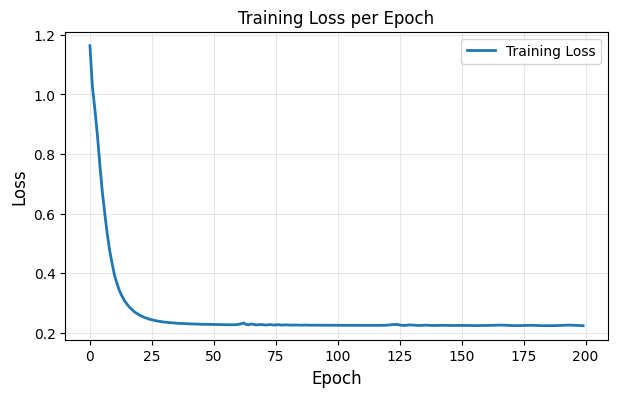

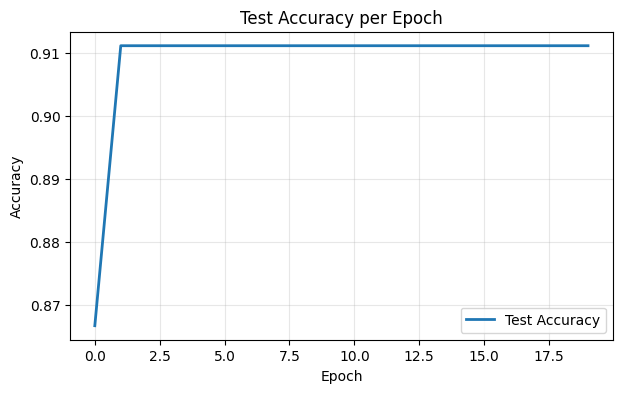

ROC AUC (OvR): 0.9906376518218624


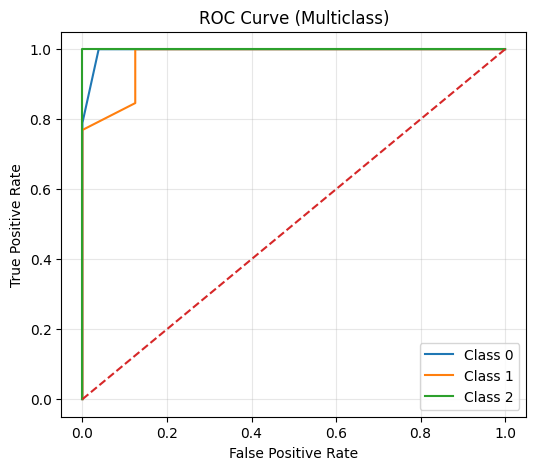

In [59]:
# Load and prepare Iris data
iris = load_iris()
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

n_inputs = X.shape[1]   # 4 features
n_classes = len(np.unique(y))  # 3 classes
n_mfs = 3  # Low, Medium, High

# Calculate mean and standard deviation for trapezoidal parameters
df = pd.DataFrame(iris.data, columns=iris.feature_names)
means = df.mean().values
stds = df.std().values
mins = df.min().values
maxs = df.max().values


# Define Trapezoidal MF module
class TrapezoidalMF(nn.Module):
    def __init__(self, means, stds, mins, maxs):
        super().__init__()
        self.means = torch.tensor(means, dtype=torch.float32)
        self.stds = torch.tensor(stds, dtype=torch.float32)
        self.mins = torch.tensor(mins, dtype=torch.float32)
        self.maxs = torch.tensor(maxs, dtype=torch.float32)

    def forward(self, x):
        """
        Input: x shape = (batch, n_features)
        Output: membership degree tensor, shape = (batch, n_features, n_mfs)
        """
        batch_size, n_features = x.shape
        mfs = torch.zeros(batch_size, n_features, 3)

        for i in range(n_features):
            mean = self.means[i]
            std = self.stds[i]
            xmin = self.mins[i]
            xmax = self.maxs[i]

            a_low, b_low, c_low, d_low = xmin, xmin, mean - (1)*std, mean
            a_med, b_med, c_med, d_med = mean - (1)*std, mean, mean, mean + (1)*std
            a_high, b_high, c_high, d_high = mean, mean + (1)*std, xmax, xmax

            # Trapezoidal fuzzy membership formulas
            for j in range(batch_size):
                xi = x[j, i]
                mfs[j, i, 0] = self.trapmf(xi, a_low, b_low, c_low, d_low)
                mfs[j, i, 1] = self.trapmf(xi, a_med, b_med, c_med, d_med)
                mfs[j, i, 2] = self.trapmf(xi, a_high, b_high, c_high, d_high)
        return mfs

    @staticmethod
    def trapmf(x, a, b, c, d):
        return torch.clamp(torch.min(torch.min((x - a) / (b - a + 1e-6),
                                               torch.tensor(1.0)),
                                     torch.min((d - x) / (d - c + 1e-6),
                                               torch.tensor(1.0))), 0, 1)


# Define full Fuzzy Neural Network
class FuzzyNeuralNet(nn.Module):
    def __init__(self, n_inputs, n_classes):
        super().__init__()
        self.fuzzy_layer = TrapezoidalMF(means, stds, mins, maxs)
        self.rule_layer = nn.Linear(n_inputs * 3, 16)   # rule base
        self.output_layer = nn.Linear(16, n_classes)

    def forward(self, x):
        mfs = self.fuzzy_layer(x)
        out = mfs.reshape(x.shape[0], -1)  # flatten
        out = torch.relu(self.rule_layer(out))
        out = self.output_layer(out)
        return out


# Instantiate and train the network
model = FuzzyNeuralNet(n_inputs, n_classes)
optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
criterion = nn.CrossEntropyLoss()

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

loss_history = []
test_acc_history = []

for epoch in range(200):
    optimizer.zero_grad()

    outputs = model(X_train_t)
    loss = criterion(outputs, y_train_t)

    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    if (epoch + 1) % 10 == 0:
        with torch.no_grad():
            test_pred = model(X_test_t)
            test_acc = (torch.argmax(test_pred, dim=1) == y_test_t).float().mean()
            test_acc_history.append(test_acc.item())

        print(f"Epoch [{epoch+1}/200] Loss: {loss.item():.4f}  Test Acc: {test_acc.item():.4f}")

# Plot training loss
plt.figure(figsize=(7,4))
plt.plot(loss_history, label="Training Loss", linewidth=2)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.title("Training Loss per Epoch")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# Plot test accuracy
plt.figure(figsize=(7,4))
plt.plot(test_acc_history, label="Test Accuracy", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Test Accuracy per Epoch")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# ROC AUC
with torch.no_grad():
    logits = model(X_test_t)
    probs = F.softmax(logits, dim=1).numpy()
y_test_np = y_test_t.numpy()

# binarize label
y_test_bin = label_binarize(y_test_np, classes=[0,1,2])
roc_auc = roc_auc_score(y_test_bin, probs, multi_class="ovr")
print("ROC AUC (OvR):", roc_auc)
plt.figure(figsize=(6,5))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], probs[:, i])
    plt.plot(fpr, tpr, label=f"Class {i}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Multiclass)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

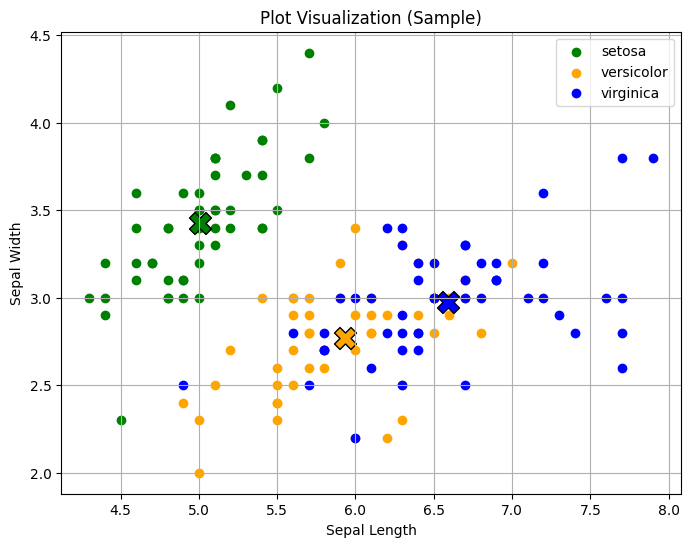

In [ ]:
# Plot data sample
class_names = ['setosa', 'versicolor', 'virginica']
colors = ['green', 'orange', 'blue']

plt.figure(figsize=(8,6))
# Plot data each class
for i, class_id in enumerate(sorted(np.unique(y))):
    mask = y == class_id
    plt.scatter(
        X[mask, 0],
        X[mask, 1],
        label=class_names[i],
        color=colors[i]
    )

# Calculate centroid
centroids = pd.DataFrame(X[:, :2], columns=['sepal width','sepal length']).groupby(y).mean()

# Plot centroid + label
for i, class_id in enumerate(centroids.index):
    x = centroids.loc[class_id, 'sepal width']
    y = centroids.loc[class_id, 'sepal length']
    plt.scatter(
        x, y,
        color=colors[i],
        marker='X',
        s=250,
        edgecolors='black'
    )

plt.xlabel(f"Sepal Length")
plt.ylabel(f"Sepal Width")
plt.title("Plot Visualization (Sample)")
plt.legend()
plt.grid()
plt.show()

In [67]:
print(centroids)

   sepal width  sepal length
0        5.006         3.428
1        5.936         2.770
2        6.588         2.974


### Simulation

In [68]:
# NOTE: RUN THIS CODE FIRST BEFORE USE ANY OTHER CODE
# Robust code: compute predictions, confusion matrix, scatter + decision map
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Find the trained model
try:
    model_used = model  # common name used earlier in the conversation
except NameError:
    try:
        model_used = fuzzy_nn
    except NameError:
        raise NameError("No trained model found. Make sure your trained model is in a variable named 'model' or 'fuzzy_nn'.")

# Ensure X_test and y_test exist
if 'X_test' not in globals():
    raise NameError("X_test not found. Make sure you have a test split variable named X_test (NumPy array).")
if 'y_test' not in globals():
    raise NameError("y_test not found. Make sure you have labels y_test (NumPy array).")

# If X_test is a pandas DataFrame, convert to numpy
if hasattr(X_test, "values"):
    X_test_np = X_test.values
else:
    X_test_np = np.array(X_test)

# Compute y_pred using the model
device = next(model_used.parameters()).device if any(p.requires_grad for p in model_used.parameters()) else torch.device("cpu")

X_tensor = torch.tensor(X_test_np, dtype=torch.float32).to(device)
model_used.eval()
with torch.no_grad():
    out = model_used(X_tensor)
    # If model returns tuple (out, other), pick first
    if isinstance(out, (tuple, list)):
        out = out[0]
    probs = torch.softmax(out, dim=1).cpu().numpy()
    y_pred = np.argmax(probs, axis=1)


<Figure size 600x500 with 0 Axes>

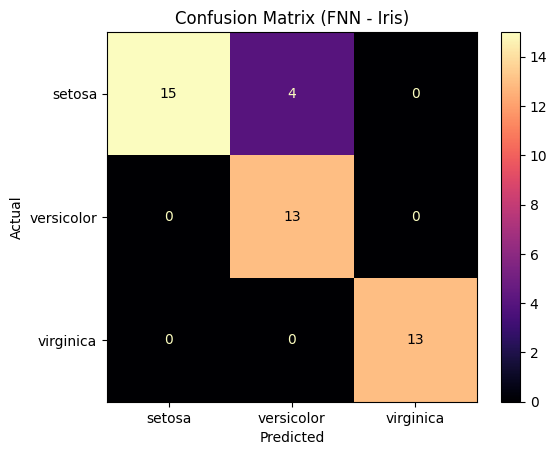

In [ ]:
# Confusion matrix
cm_test = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_test,
                            display_labels=['setosa', 'versicolor', 'virginica'])
disp.plot(cmap='magma', values_format='d')
#sns.heatmap(cm_test,
#            annot=True,
#            cmap="magma",
#            fmt="d")

plt.title("Confusion Matrix (FNN - Iris)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [73]:
hasil = pd.DataFrame(X_test_np[:, :2])
hasil.columns = ['sepal length (cm)', 'sepal width (cm)']
hasil = pd.concat([hasil, pd.Series(y_pred, name='Class')], axis=1)

hasil_centroids = hasil.groupby('Class')[['sepal length (cm)', 'sepal width (cm)']].mean()

centroids_original = hasil_centroids.copy()
# Inverse from this sample
centroids_original['sepal length (cm)'] = (
    centroids_original['sepal length (cm)'] * (7.9 - 4.3) + 4.3
)

centroids_original['sepal width (cm)'] = (
    centroids_original['sepal width (cm)'] * (4.4 - 2.0) + 2.0
)

print(centroids_original)


       sepal length (cm)  sepal width (cm)
Class                                     
0               5.034118          3.570909
1               6.062630          3.206417
2               6.808597          3.023776


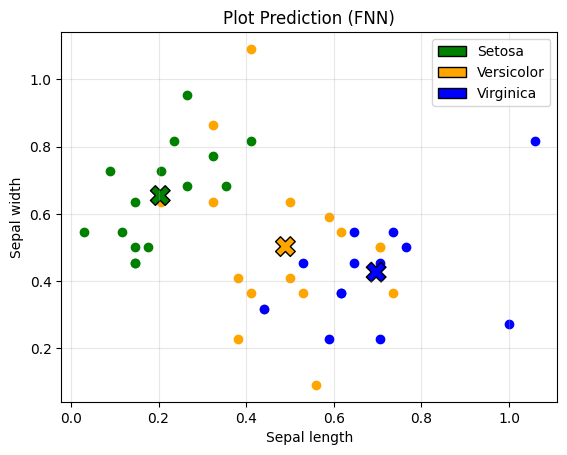

In [ ]:
# Plot prediction results
class_names = ['setosa', 'versicolor', 'virginica']
colors = ['green', 'orange', 'blue']
marker_colors = {1: 'green', 2: 'orange', 3: 'blue'}


for i, class_id in enumerate(sorted(np.unique(hasil["Class"]))):
    mask = hasil["Class"] == class_id
    plt.scatter(hasil[mask]['sepal length (cm)'], hasil[mask]['sepal width (cm)'], c=colors[i],
                label=f'{class_names[i]}')

# Plot centroids
plt.scatter(hasil_centroids['sepal length (cm)'], hasil_centroids['sepal width (cm)'], 
            c=[marker_colors[1], marker_colors[2], marker_colors[3]], marker='X', s=200, 
            edgecolors='black', linewidth=1)

# Add custom legend for centroids
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=marker_colors[1], edgecolor='black', label='Setosa'),
                   Patch(facecolor=marker_colors[2], edgecolor='black', label='Versicolor'),
                   Patch(facecolor=marker_colors[3], edgecolor='black', label='Virginica')]
plt.legend(handles=legend_elements)

plt.xlabel(f'Sepal length')
plt.ylabel(f'Sepal width')
plt.title('Plot Prediction (FNN)')
plt.grid(True, alpha=0.3)
plt.show()